# Sanity Check — UL / SHELL / HSBC
Questo notebook esegue lo stesso controllo di `src/analysis_ul_shell_hsbc.py`  
ma con output formattati e grafici, per una verifica visiva immediata dei dati processati.

In [3]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# aggiunge la root del progetto al path così possiamo importare da src/
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

PROCESSED_DIR = ROOT / "data/processed"
SYMBOLS = ["UL", "SHELL", "HSBC"]

## 1 — Caricamento dei dati

In [4]:
# carica MBP e trades per tutti e tre i titoli in due dizionari
# chiave = nome simbolo, valore = DataFrame
mbp_data    = {}
trades_data = {}

for sym in SYMBOLS:
    mbp_path    = PROCESSED_DIR / f"{sym}_mbp1.parquet"
    trades_path = PROCESSED_DIR / f"{sym}_trades.parquet"

    if mbp_path.exists():
        mbp_data[sym] = pd.read_parquet(mbp_path)
        print(f"[OK] {sym} MBP:    {mbp_data[sym].shape}")
    else:
        print(f"[MANCANTE] {mbp_path}")

    if trades_path.exists():
        trades_data[sym] = pd.read_parquet(trades_path)
        print(f"[OK] {sym} Trades: {trades_data[sym].shape}")
    else:
        print(f"[MANCANTE] {trades_path}")

[OK] UL MBP:    (5271995, 10)
[OK] UL Trades: (297825, 7)
[OK] SHELL MBP:    (12034572, 10)
[OK] SHELL Trades: (9332749, 7)
[OK] HSBC MBP:    (9164971, 10)
[OK] HSBC Trades: (225538, 7)


## 2 — Struttura dei DataFrame

In [5]:
# mostra le colonne e i tipi di dato per ogni titolo
# utile per verificare che il preprocessing abbia prodotto le colonne attese
for sym in SYMBOLS:
    if sym not in mbp_data:
        continue
    print(f"\n{'─'*50}")
    print(f"  {sym} — MBP dtypes")
    print(f"{'─'*50}")
    print(mbp_data[sym].dtypes.to_string())
    print(f"\n  {sym} — Trades dtypes")
    print(trades_data[sym].dtypes.to_string())


──────────────────────────────────────────────────
  UL — MBP dtypes
──────────────────────────────────────────────────
ts_event       datetime64[ns, UTC]
symbol                         str
bid_px_00                  float64
ask_px_00                  float64
bid_sz_00                   uint32
ask_sz_00                   uint32
spread                     float64
mid                        float64
event_date                  object
ts_event_ms                  int64

  UL — Trades dtypes
ts_event       datetime64[ns, UTC]
symbol                         str
price                      float64
size                        uint32
side                           str
event_date                  object
ts_event_ms                  int64

──────────────────────────────────────────────────
  SHELL — MBP dtypes
──────────────────────────────────────────────────
ts_event       datetime64[ns, UTC]
symbol                         str
bid_px_00                  float64
ask_px_00                  float6

## 3 — Anteprima righe

In [6]:
# mostra le prime 3 righe di MBP per ogni titolo
for sym in SYMBOLS:
    if sym not in mbp_data:
        continue
    print(f"\n=== {sym} — MBP head ===")
    display(mbp_data[sym].head(3))


=== UL — MBP head ===


,ts_event,symbol,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,spread,mid,event_date,ts_event_ms
0,2026-03-10 08:00:00.006091869+00:00,UL,66.06,67.03,550,550,0.97,66.545,2026-03-10,1773129600006
1,2026-03-10 08:00:00.006385666+00:00,UL,66.06,66.97,550,410,0.91,66.515,2026-03-10,1773129600006
2,2026-03-10 08:00:00.006510271+00:00,UL,66.24,66.97,410,410,0.73,66.605,2026-03-10,1773129600006



=== SHELL — MBP head ===


,ts_event,symbol,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,spread,mid,event_date,ts_event_ms
0,2026-03-10 08:00:00.006572323+00:00,SHELL,84.46,85.41,410,410,0.95,84.935,2026-03-10,1773129600006
1,2026-03-10 08:00:00.006715994+00:00,SHELL,84.46,85.41,410,820,0.95,84.935,2026-03-10,1773129600006
2,2026-03-10 08:00:00.006728884+00:00,SHELL,84.48,85.41,410,820,0.93,84.945,2026-03-10,1773129600006



=== HSBC — MBP head ===


,ts_event,symbol,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,spread,mid,event_date,ts_event_ms
0,2026-03-10 08:00:00.002840418+00:00,HSBC,84.05,87.65,270,330,3.60,85.85,2026-03-10,1773129600002
1,2026-03-10 08:00:00.003951199+00:00,HSBC,84.11,87.65,330,330,3.54,85.88,2026-03-10,1773129600003
2,2026-03-10 08:00:00.007660810+00:00,HSBC,86.63,87.65,270,330,1.02,87.14,2026-03-10,1773129600007


## 4 — Statistiche dello spread bid-ask

In [7]:
# spread = ask - bid: deve essere sempre >= 0
# valori negativi o molto grandi indicano dati corrotti
spread_stats = {}
for sym in SYMBOLS:
    if sym not in mbp_data:
        continue
    spread_stats[sym] = mbp_data[sym]["spread"].describe()

# affianca le statistiche dei tre titoli in un'unica tabella per confrontarle facilmente
display(pd.DataFrame(spread_stats).T.round(6))

,count,mean,std,min,25%,50%,75%,max
UL,5271995.0,0.024384,0.107537,0.01,0.01,0.01,0.02,12.00
SHELL,12034572.0,0.021375,0.118808,0.01,0.01,0.01,0.02,92.47
HSBC,9164971.0,0.038673,0.143341,0.01,0.02,0.02,0.05,49.34


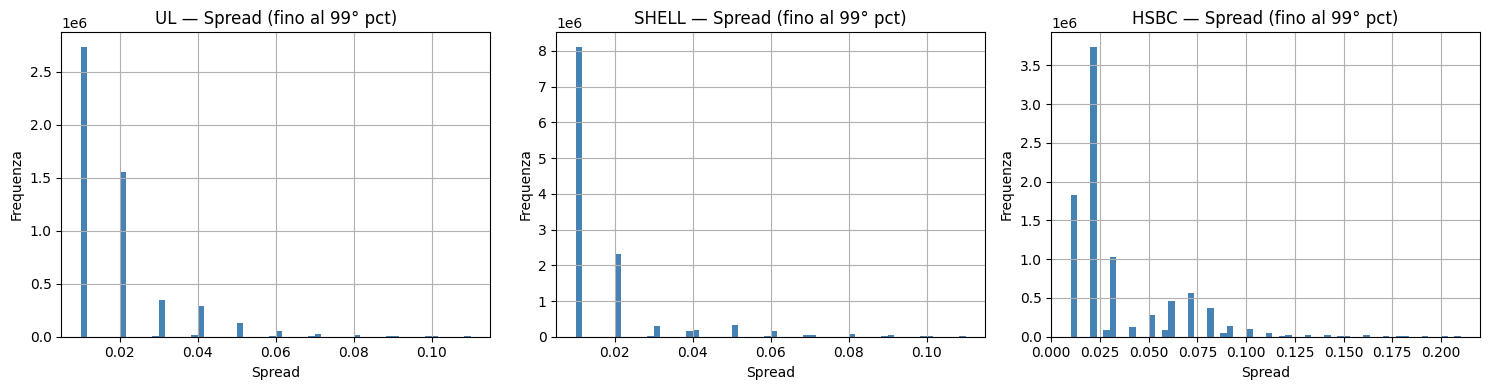

In [8]:
# istogramma dello spread per ogni titolo
fig, axes = plt.subplots(1, len(mbp_data), figsize=(5 * len(mbp_data), 4))
if len(mbp_data) == 1:
    axes = [axes]

for ax, sym in zip(axes, mbp_data):
    spread = mbp_data[sym]["spread"]
    # usa solo il 99° percentile per tagliare gli outlier estremi nel grafico
    cap = spread.quantile(0.99)
    spread[spread <= cap].hist(bins=60, ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"{sym} — Spread (fino al 99° pct)")
    ax.set_xlabel("Spread")
    ax.set_ylabel("Frequenza")

plt.tight_layout()
plt.show()

## 5 — Statistiche dei prezzi trade

In [9]:
price_stats = {}
for sym in SYMBOLS:
    if sym not in trades_data:
        continue
    if "price" in trades_data[sym].columns:
        price_stats[sym] = trades_data[sym]["price"].describe()

display(pd.DataFrame(price_stats).T.round(4))

,count,mean,std,min,25%,50%,75%,max
UL,297825.0,59.7208,3.4708,54.55,56.13,59.83,61.94,66.91
SHELL,9332749.0,171.3901,23.1909,83.76,173.25,176.85,182.41,188.87
HSBC,225538.0,82.2610,3.7473,74.89,79.56,81.05,84.83,91.68


## 6 — Copertura temporale (eventi per giorno)

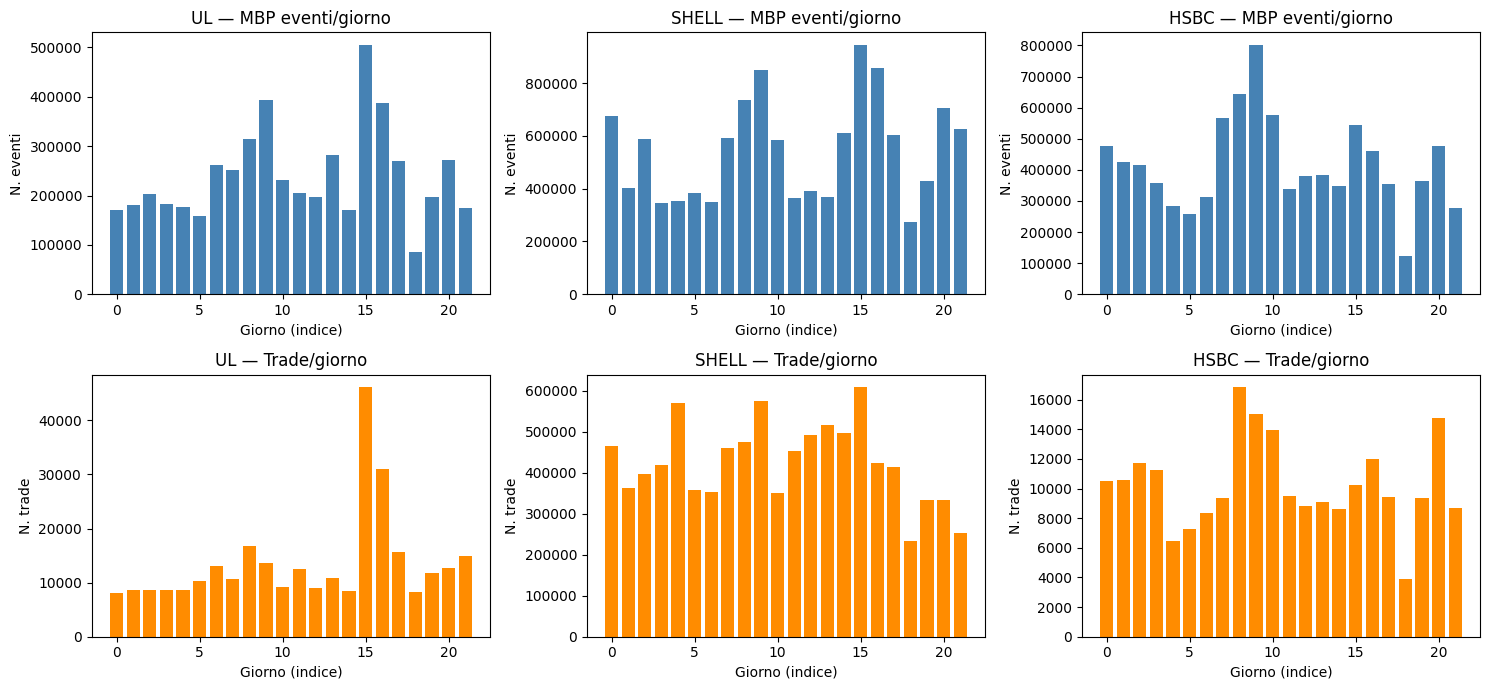

In [10]:
# conta quanti eventi MBP e quante trade ci sono per ogni giorno
# un giorno con molti meno dati degli altri è un segnale da investigare
fig, axes = plt.subplots(2, len(mbp_data), figsize=(5 * len(mbp_data), 7))

for col, sym in enumerate(mbp_data):
    # riga 0: eventi MBP per giorno
    mbp_per_day = mbp_data[sym].groupby("event_date").size()
    axes[0, col].bar(range(len(mbp_per_day)), mbp_per_day.values, color="steelblue")
    axes[0, col].set_title(f"{sym} — MBP eventi/giorno")
    axes[0, col].set_xlabel("Giorno (indice)")
    axes[0, col].set_ylabel("N. eventi")

    # riga 1: trade per giorno
    trades_per_day = trades_data[sym].groupby("event_date").size()
    axes[1, col].bar(range(len(trades_per_day)), trades_per_day.values, color="darkorange")
    axes[1, col].set_title(f"{sym} — Trade/giorno")
    axes[1, col].set_xlabel("Giorno (indice)")
    axes[1, col].set_ylabel("N. trade")

plt.tight_layout()
plt.show()

In [11]:
# controlla se ci sono date presenti in MBP ma non in trades o viceversa
# date mancanti in uno dei due dataset causano problemi nel join cross-market
for sym in SYMBOLS:
    if sym not in mbp_data or sym not in trades_data:
        continue
    mbp_dates    = set(mbp_data[sym]["event_date"].unique())
    trades_dates = set(trades_data[sym]["event_date"].unique())
    only_mbp    = mbp_dates - trades_dates
    only_trades = trades_dates - mbp_dates
    if only_mbp or only_trades:
        print(f"\n*** {sym} — date non allineate ***")
        if only_mbp:    print(f"  Solo in MBP:    {sorted(only_mbp)}")
        if only_trades: print(f"  Solo in trades: {sorted(only_trades)}")
    else:
        print(f"[OK] {sym} — MBP e trades hanno le stesse date")

[OK] UL — MBP e trades hanno le stesse date
[OK] SHELL — MBP e trades hanno le stesse date
[OK] HSBC — MBP e trades hanno le stesse date
